In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1635 pairs
['a', 'acqua', 'acque', 'aeroporti', 'aeroporto'] ['a', 'agua', 'aguas', 'aeropuertos', 'aeropuerto']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'ì', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 37
Max length of spanish words:  15
Max length of italian words:  15
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[-5.2641e-01, -1.5209e-01,  4.9511e-01,  7.0616e-01,  5.8252e-02,
          1.0626e+00, -2.1676e-01,  2.7710e-01, -9.3917e-01,  6.6079e-01,
         -1.4209e-03,  8.4497e-01,  4.9109e-02,  1.4437e-01,  1.0612e-01,
          2.9958e-01,  1.9347e+00, -9.6358e-01, -1.3648e+00,  1.3639e-01,
          1.0587e+00, -3.0486e-01, -1.7021e-02,  9.9920e-04, -1.2581e+00,
          5.0815e-01,  1.2087e-01,  6.3383e-01,  9.3662e-03,  1.4778e+00,
          1.0458e-01, -5.6542e-01],
   

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 1.4099e-01,  7.7811e-02, -9.9236e-01,  2.0577e-01, -4.9424e-01,
          -6.8345e-01,  4.9872e-02,  1.3271e-01, -9.8748e-01,  1.5682e-01,
          -7.3678e-01,  1.0828e+00, -2.6145e-01, -9.9943e-01, -3.5925e-02,
          -5.5771e-01, -5.2922e-01,  5.9715e-01, -1.7456e-01, -1.5203e-01,
           4.8978e-01, -1.7616e-01,  6.9189e-01,  1.1627e+00,  5.0410e-01,
          -6.1251e-01,  9.7933e-01, -4.1017e-01, -9.0132e-01, -1.6829e-01,
           1.2480e-01,  1.3120e+00, -7.9066e-01,  1.3531e-01,  1.8195e-01,
          -2.8090e-01,  7.5794e-01],
         [ 2.4507e-01,  1.1407e+00, -1.4732e+00, -1.0845e+00, -7.8168e-01,
           1.6824e-01,  7.0483e-01,  3.4857e-01,  8.2000e-01,  8.9796e-02,
          -1.0496e+00,  2.2816e-01,  7.6446e-01, -1.0807e-01,  6.7140e-01,
          -9.9282e-01, -5.0045e-01,  7.2998e-01, -1.2448e-01, -3.7846e-01,
          -4.2243e-02,  2.1126e-01, -8.7632e-01,  1.8418e+00, -3.4869e-01,
          -3.5554e-01, -8.2797e-02, -6.0452e-02, -5.4387e-02,  

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1184,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1221,
 'criterion': 0,
 'TOTAL': 91493}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

# here weight_decya = 1e-2
trafo1_weight_decay = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)
trafo2_weight_decay = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)


print('trafo1')
print(trafo1.count_parameters_by_module())
print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo1_wd')
trafo1_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2_wd')
trafo2_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 592, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 3975}
trafo2
{'embed': 1184, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1221, 'criterion': 0, 'TOTAL': 138213}
train trafo1
Epoch  0 / 500  loss =  3.8325459957122803  loss_eval =  3.8152971267700195
Epoch  100 / 500  loss =  1.6807889938354492  loss_eval =  1.758995532989502
Epoch  200 / 500  loss =  1.336971640586853  loss_eval =  1.474112629890442
Epoch  300 / 500  loss =  1.1792609691619873  loss_eval =  1.372930645942688
Epoch  400 / 500  loss =  1.109207272529602  loss_eval =  1.336832880973816
train trafo2
Epoch  0 / 500  loss =  3.7905430793762207  loss_eval =  3.782959461212158
Epoch  100 / 500  loss =  0.2768033444881439  loss_eval =  0.9149892926216125
Epoch  200 / 500  loss =  0.002515897387638688  loss_eval =  1.1743968725204468
Epoch  300 / 500  loss =  0.0018918249988928437  loss_eval =  1.227964520454406

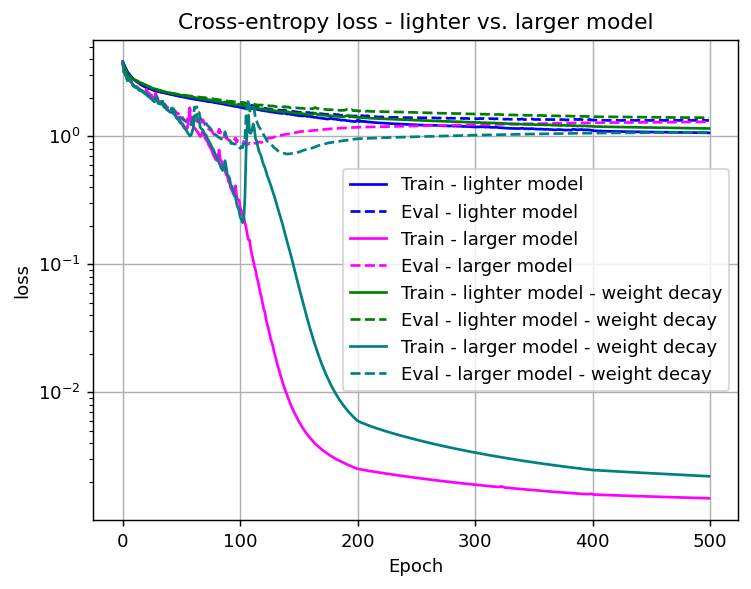

In [6]:
plt.figure(dpi = 130)
plt.title('Cross-entropy loss - lighter vs. larger model')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - lighter model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - lighter model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses, color = 'green', label = 'Train - lighter model - weight decay')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses_eval, '--', color = 'green', label = 'Eval - lighter model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses, color = 'teal', label = 'Train - larger model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses_eval, '--', color = 'teal', label = 'Eval - larger model - weight decay')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [7]:

# intermediate size
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

print('trafo3')
print(trafo3.count_parameters_by_module())
print('train trafo3')
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo2_120epochs = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
print('train trafo2_120epochs')
trafo2_120epochs.fit_from_txt("it_es_cognates.txt", n_epochs=120)

trafo3
{'embed': 592, 'pos_encoding': 0, 'encoder': 3376, 'decoder': 4544, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 9141}
train trafo3
Epoch  0 / 500  loss =  3.7818822860717773  loss_eval =  3.765824794769287
Epoch  100 / 500  loss =  0.9322073459625244  loss_eval =  1.1349070072174072
Epoch  200 / 500  loss =  0.6621124148368835  loss_eval =  0.9818911552429199
Epoch  300 / 500  loss =  0.2881588041782379  loss_eval =  0.8318792581558228
Epoch  400 / 500  loss =  0.19696742296218872  loss_eval =  0.8806634545326233
train trafo2_120epochs
Epoch  0 / 120  loss =  3.8362441062927246  loss_eval =  3.8329737186431885
Epoch  100 / 120  loss =  0.24414698779582977  loss_eval =  0.8168964982032776


In [8]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna", "passato"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
     print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20}| {expected_spanish_cognates_2[k]:<20}  | {expected_spanish_cognates_2_120ep[k]:<20}")
italian_words = ["parato", "parata", "parati", "parate", "ottone", "castoro", "matti", "passata", "passate", "passante", "incantato", "incantando"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20}| {expected_spanish_cognates_2[k]:<20}  | {expected_spanish_cognates_2_120ep[k]:<20}")

Words in training dataset
Italian         | output light model   | output medium model | output larger model  | output larger model 120 ep
-----------------------------------------------------------
gatto           | jatado               | gato                | gato                  | gato                
nave            | nadelles             | nave                | nave                  | nuvas               
croci           | cruro                | cruzes              | cruces                | cruces              
croce           | crure                | cruz                | cruz                  | cruz                
dito            | dicido               | dedo                | dedo                  | dido                
stretta         | estada               | estrecha            | estrecha              | estrecha            
stretti         | estres               | estrechos           | estrechos             | estrechos           
stretto         | estres               | estr

Epoch  0 / 1000  loss =  3.680457353591919  loss_eval =  3.7026774883270264
Epoch  100 / 1000  loss =  1.5166181325912476  loss_eval =  1.5852618217468262
Epoch  200 / 1000  loss =  1.168622374534607  loss_eval =  1.2815515995025635
Epoch  300 / 1000  loss =  1.0417455434799194  loss_eval =  1.185774564743042
Epoch  400 / 1000  loss =  0.9676316976547241  loss_eval =  1.1475577354431152
Epoch  500 / 1000  loss =  0.9201792478561401  loss_eval =  1.1306326389312744
Epoch  600 / 1000  loss =  0.900986909866333  loss_eval =  1.1251771450042725
Epoch  700 / 1000  loss =  0.8817473649978638  loss_eval =  1.1192091703414917
Epoch  800 / 1000  loss =  0.8692000508308411  loss_eval =  1.1174285411834717
Epoch  900 / 1000  loss =  0.8627723455429077  loss_eval =  1.1153315305709839
Epoch  0 / 1000  loss =  3.7816524505615234  loss_eval =  3.7796828746795654
Epoch  100 / 1000  loss =  0.8740427494049072  loss_eval =  1.0869646072387695
Epoch  200 / 1000  loss =  0.43820810317993164  loss_eval = 

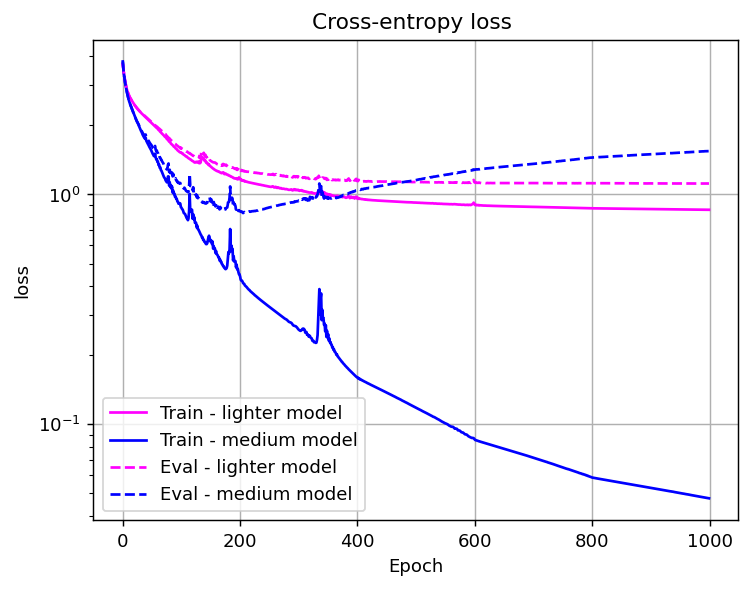

In [15]:
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=1000)
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=1000)

plt.figure(dpi = 130)
plt.title('Cross-entropy loss ')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'magenta', label = 'Train - lighter model')
plt.semilogy(trafo3.epochs, trafo3.losses, color = 'blue', label = 'Train - medium model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'magenta', label = 'Eval - lighter model')
plt.semilogy(trafo1.epochs, trafo3.losses_eval, '--', color = 'blue', label = 'Eval - medium model')
plt.legend()
plt.show()

# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lmodels give ok results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers. using weight decay with lambda = 1e-2 does not seem to make much of a difference

for now, the medium size model seems to have the best results on words not in the training dataset

need bigger dataset, as I add more words the model get **slowly** better on the eval dataset/unknown words

**regularization: try dropout and change weight decay parameter**